# From Sleep to Success: Exploring the Relationship between Sleep and GPA

# **Introduction**

<div align="center">
    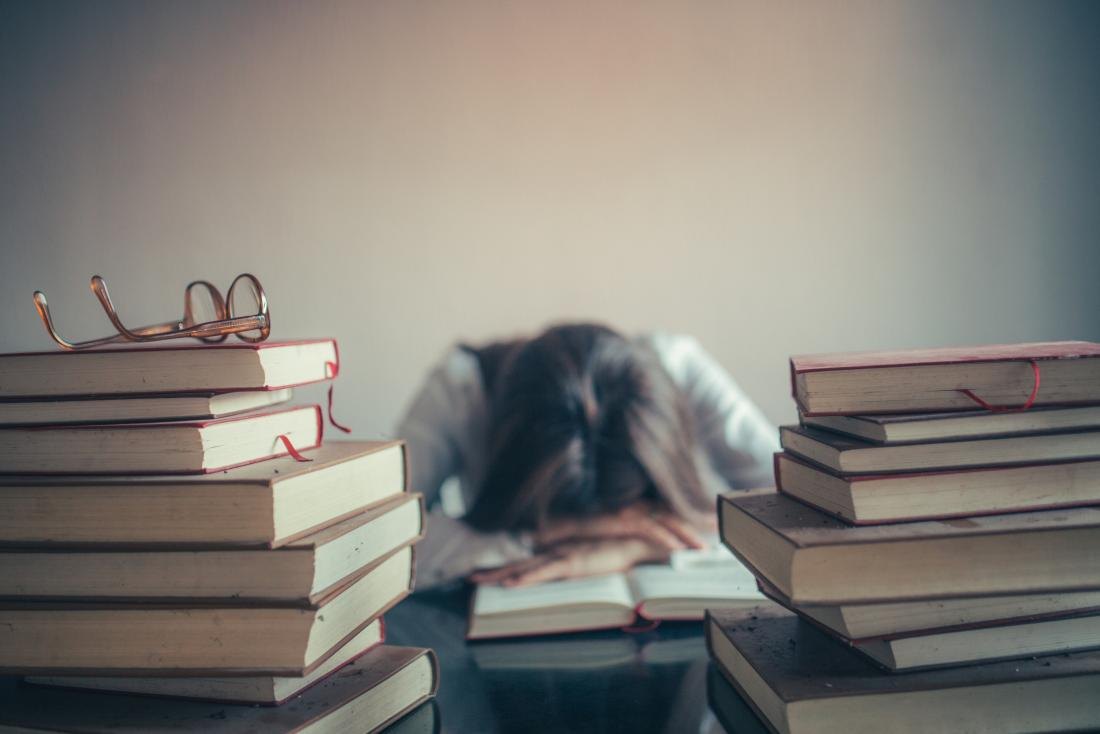
</div>
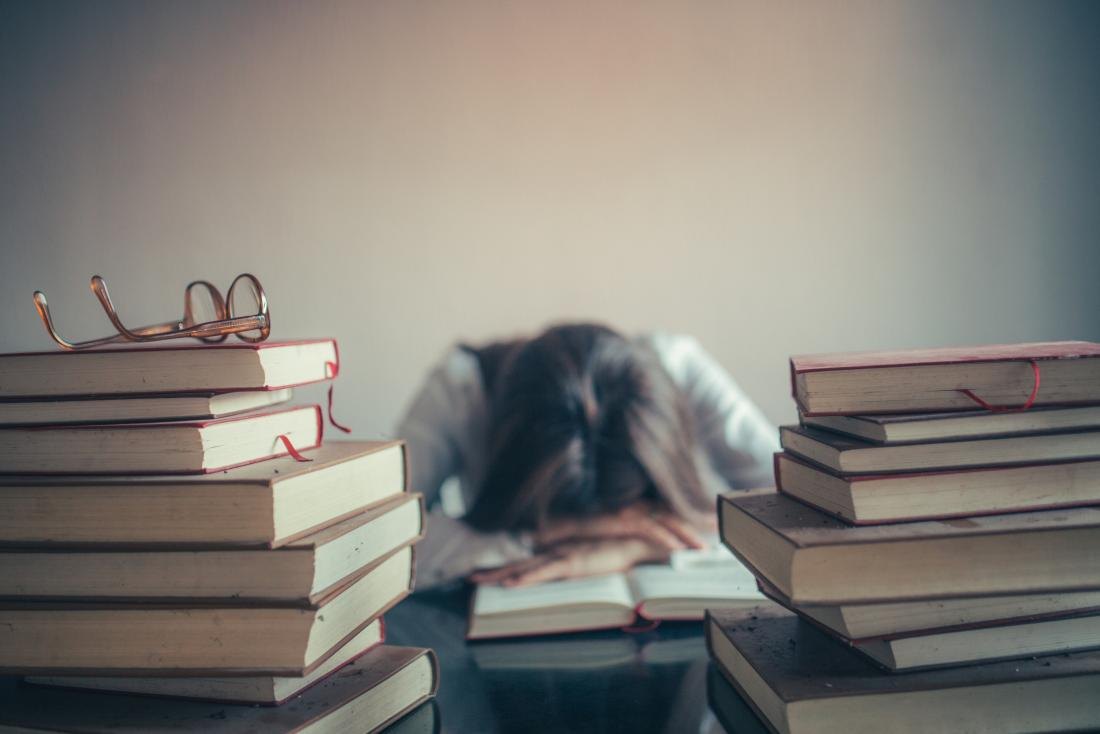
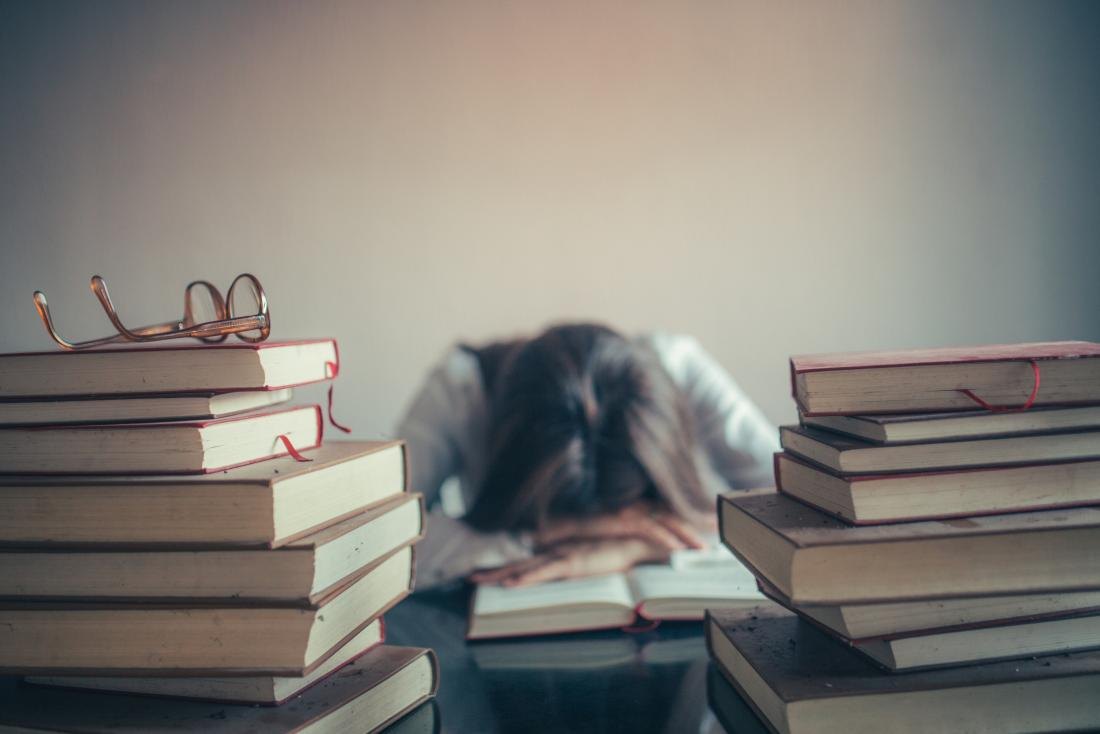
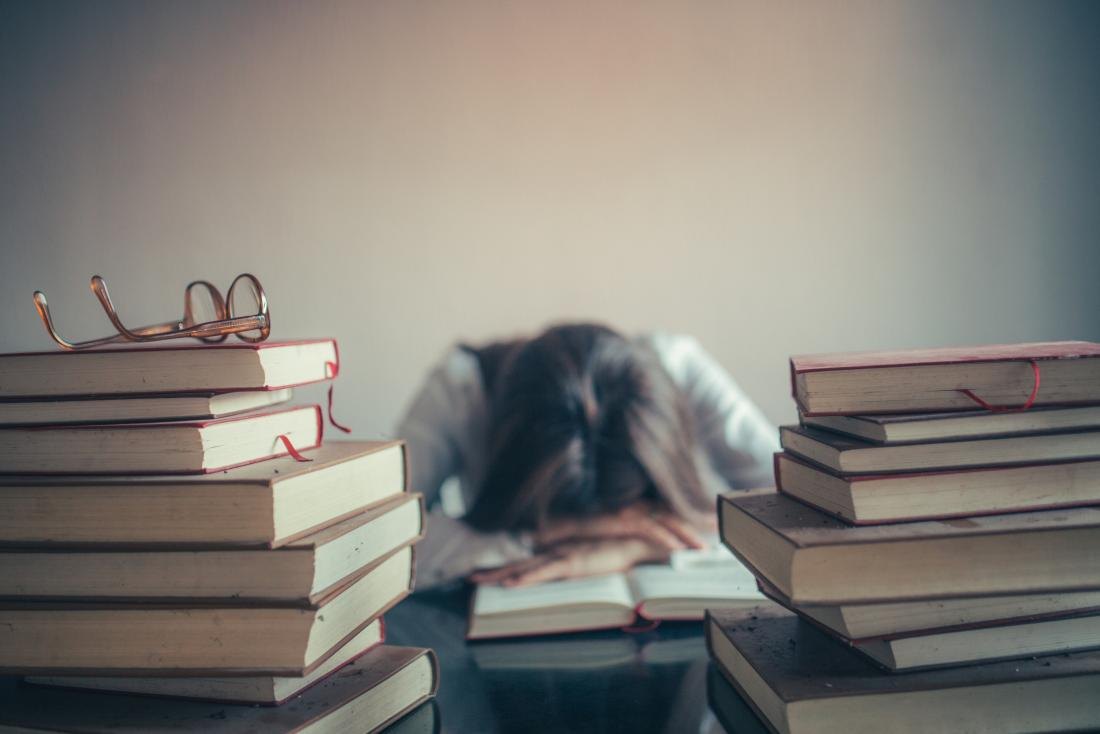

Sleep plays a crucial role in cognitive performance, memory consolidation, and overall well-being. University students often sacrifice sleep because of coursework, exams, and social activities, but does sleeping less actually affect academic performance?

In this project, we analyze a dataset containing students' sleep habits and academic information to investigate the relationship between sleep behavior and Grade Point Average (GPA).

This notebook demonstrates a complete data analytics workflow, including data cleaning, exploratory data analysis (EDA), statistical analysis, and visualization.

The analysis is performed using Python libraries such as Pandas, NumPy, Matplotlib, and Seaborn.

# Objectives

**The main objectives of this analysis are:**
* Understand the structure of the dataset.
* Clean and prepare the data.
* Explore students' sleep habits.
* Investigate the relationship between sleep duration and GPA.
* Compare sleep patterns across demographic groups.
* Identify factors associated with higher academic performance.
* Visualize findings using informative charts.
* Generate actionable insights based on the analysis.

# Business Questions

**Key Questions:**
1. What is the average GPA of students?
2. How many hours do students sleep on average?
3. Does sleeping less than six hours affect GPA?
4. Does bedtime consistency influence academic performance?
5. Do students with higher GPAs sleep more?
6. Are there differences in sleep behavior between male and female students?
7. Does daytime sleeping compensate for poor nighttime sleep?
8. Which factors appear to have the strongest relationship with GPA?

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub

/kaggle/input/datasets/kylefengkfeng209/sleep-vs-gpa-in-college/study_cohort_reference.csv
/kaggle/input/datasets/kylefengkfeng209/sleep-vs-gpa-in-college/college_sleep_and_gpa.csv


# Loading Dataset

In [2]:
sleep_gpa_df = pd.read_csv("/kaggle/input/datasets/kylefengkfeng209/sleep-vs-gpa-in-college/college_sleep_and_gpa.csv")

print("=" * 60)
print("📊 Dataset Overview")
print("=" * 60)

# Dataset dimensions
print(f"\nRows: {sleep_gpa_df.shape[0]}")
print(f"Columns: {sleep_gpa_df.shape[1]}")

# First 5 rows
display(sleep_gpa_df.head())

# Dataset information
print("\nDataset Information")
sleep_gpa_df.info()

# Statistical summary
display(sleep_gpa_df.describe())

# Missing values
missing = sleep_gpa_df.isnull().sum()
missing = missing[missing > 0]

print("\nMissing Values")
if missing.empty:
    print("No missing values found.")
else:
    display(missing)

# Duplicate rows
duplicates = sleep_gpa_df.duplicated().sum()
print(f"\nDuplicate Rows: {duplicates}")


📊 Dataset Overview

Rows: 634
Columns: 22


,student_id,study,university,semester,cohort_code,gender,first_generation,underrepresented,avg_sleep_minutes,avg_sleep_hours,...,bedtime_variability,nights_tracked_fraction,prior_gpa,term_gpa,gpa_change,term_units,term_load_z,under_6h_sleep,sleep_bracket,sleep_midpoint_clock
0,293,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,0.0,370.0,6.17,...,0.0500,0.931,4.00,3.76,-0.24,49.0,0.112,0,6-6.5h,07:20
1,294,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,0.0,406.8,6.78,...,0.0476,0.862,4.00,3.55,-0.45,49.0,0.112,0,6.5-7h,05:00
2,297,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,1.0,253.8,4.23,...,0.1639,0.586,3.00,3.59,0.59,46.0,-0.604,1,<5.5h,05:38
3,303,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,0.0,411.9,6.86,...,0.7854,0.931,3.80,3.46,-0.34,39.0,-2.275,0,6.5-7h,07:52
4,304,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,1.0,408.1,6.80,...,0.1538,0.931,3.17,3.50,0.33,39.0,-2.275,0,6.5-7h,04:54



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   student_id               634 non-null    int64  
 1   study                    634 non-null    int64  
 2   university               634 non-null    object 
 3   semester                 634 non-null    object 
 4   cohort_code              634 non-null    object 
 5   gender                   631 non-null    object 
 6   first_generation         630 non-null    float64
 7   underrepresented         633 non-null    float64
 8   avg_sleep_minutes        634 non-null    float64
 9   avg_sleep_hours          634 non-null    float64
 10  daytime_sleep_minutes    634 non-null    float64
 11  sleep_midpoint_minutes   634 non-null    float64
 12  bedtime_variability      634 non-null    float64
 13  nights_tracked_fraction  634 non-null    float64
 14  prior

,student_id,study,first_generation,underrepresented,avg_sleep_minutes,avg_sleep_hours,daytime_sleep_minutes,sleep_midpoint_minutes,bedtime_variability,nights_tracked_fraction,prior_gpa,term_gpa,gpa_change,term_units,term_load_z,under_6h_sleep
count,634.000000,634.000000,630.000000,633.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,487.000000,487.000000,634.000000
mean,13005.892744,3.181388,0.166667,0.187994,397.324763,6.622098,41.165615,398.678707,0.451687,0.867478,3.465584,3.449587,-0.015997,29.392197,-0.000057,0.208202
std,26496.593477,1.317125,0.377213,0.391016,50.855641,0.847741,27.388294,72.712017,1.393631,0.178999,0.437578,0.500463,0.403109,17.642780,1.000017,0.406343
min,1.000000,1.000000,0.000000,0.000000,194.800000,3.250000,2.300000,247.100000,0.004500,0.214000,1.210000,0.350000,-1.877000,5.000000,-3.983000,0.000000
25%,178.000000,2.000000,0.000000,0.000000,366.950000,6.112500,23.100000,345.175000,0.074700,0.821000,3.232250,3.233000,-0.189500,15.000000,-0.551000,0.000000
50%,358.500000,3.000000,0.000000,0.000000,400.350000,6.675000,35.000000,388.250000,0.135000,0.932000,3.558000,3.556000,0.000000,17.000000,0.041000,0.000000
75%,592.750000,4.000000,0.000000,0.000000,430.100000,7.170000,51.250000,437.625000,0.291700,1.000000,3.789500,3.810000,0.193750,48.000000,0.560000,0.000000
max,99978.000000,5.000000,2.000000,1.000000,587.700000,9.790000,292.300000,724.700000,20.849200,1.000000,4.000000,4.000000,1.332000,73.000000,4.055000,1.000000



Missing Values


gender                3
first_generation      4
underrepresented      1
term_units          147
term_load_z         147
dtype: int64


Duplicate Rows: 0


# Data Cleaning

In [3]:
# Checking missing values
missing_values = (
    sleep_gpa_df.isnull()
    .sum()
    .reset_index()
)

# Rename columns
missing_values.columns = ["Column", "Missing Values"]

# Calculate percentage
missing_values["Percentage"] = (
    missing_values["Missing Values"] / len(sleep_gpa_df) * 100
).round(2)

# Keep only columns with missing values
missing_values = missing_values[
    missing_values["Missing Values"] > 0
]

display(missing_values)

,Column,Missing Values,Percentage
5,gender,3,0.47
6,first_generation,4,0.63
7,underrepresented,1,0.16
17,term_units,147,23.19
18,term_load_z,147,23.19


**Observation**: There is a small number of missing values. Most columns are complete but term_units and term_load_z contain the majority of missing values.

In [4]:
#Checking for duplicate rows
duplicates = sleep_gpa_df.duplicated().sum()
print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


**Observation:** No duplicate rows were found in the dataset.

In [5]:
#Checking data types
display(sleep_gpa_df.dtypes.to_frame("Data Type"))

,Data Type
student_id,int64
study,int64
university,object
semester,object
cohort_code,object
gender,object
first_generation,float64
underrepresented,float64
avg_sleep_minutes,float64
avg_sleep_hours,float64


**Observation:** The dataset contains both numerical and categorical variables, which will require different visualization and analysis techniques.

In [6]:
#Inspecting missing values
sleep_gpa_df[sleep_gpa_df["gender"].isnull()]

,student_id,study,university,semester,cohort_code,gender,first_generation,underrepresented,avg_sleep_minutes,avg_sleep_hours,...,bedtime_variability,nights_tracked_fraction,prior_gpa,term_gpa,gpa_change,term_units,term_load_z,under_6h_sleep,sleep_bracket,sleep_midpoint_clock
13,334,1,Carnegie Mellon University,Spring 2018,lac2,NaN,0.0,0.0,315.6,5.26,...,0.1719,1.000,3.200,3.63,0.430,55.0,1.543,1,<5.5h,06:16
280,424,3,University of Washington,Spring 2019,uw2,NaN,0.0,0.0,480.6,8.01,...,0.0964,1.000,3.141,2.80,-0.341,15.0,0.041,0,7.5h+,04:28
568,222,5,Carnegie Mellon University,Spring 2017,lac1,NaN,0.0,0.0,367.4,6.12,...,0.1612,0.931,3.500,3.40,-0.100,53.0,0.560,0,6-6.5h,05:46


In [7]:
#Overall quality of the Data
quality = pd.DataFrame({
    "Data Type": sleep_gpa_df.dtypes,
    "Missing Values": sleep_gpa_df.isnull().sum(),
    "Unique Values": sleep_gpa_df.nunique()
})

display(quality)

,Data Type,Missing Values,Unique Values
student_id,int64,0,547
study,int64,0,5
university,object,0,3
semester,object,0,4
cohort_code,object,0,5
gender,object,3,2
first_generation,float64,4,3
underrepresented,float64,1,2
avg_sleep_minutes,float64,0,522
avg_sleep_hours,float64,0,268


# Exploratory Data Analysis

In this section, we explore the dataset through visualizations to understand students' sleep patterns, academic performance, and the relationships between different variables.

# 1. Distribution of GPA (Histogram)

Question: What is the distribution of students' GPA?

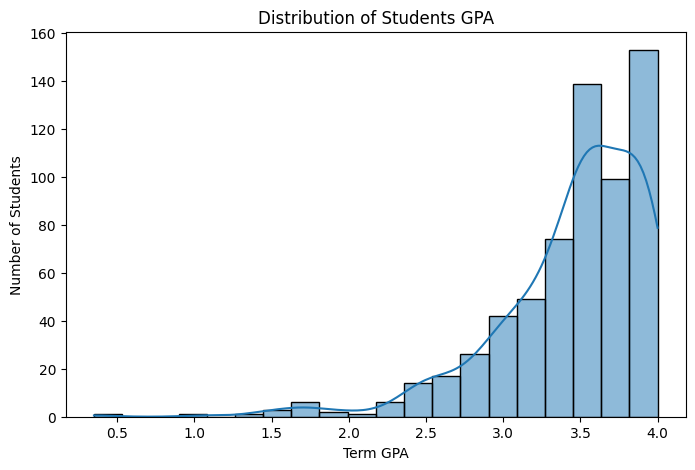

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=sleep_gpa_df,
    x='term_gpa',
    bins=20,
    kde=True
)

plt.title("Distribution of Students GPA")
plt.xlabel("Term GPA")
plt.ylabel("Number of Students")

plt.show()

**Observation:** The most comment GPA according to the distribution is 3.5-4.0

# 2. Distribution of Sleep Hours

Question: What is the distribution of Average Sleep Hours?

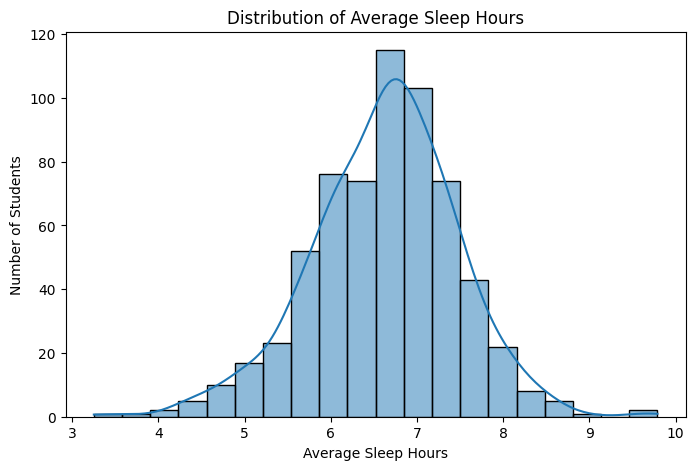

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=sleep_gpa_df,
    x="avg_sleep_hours",
    bins=20,
    kde=True
)

plt.title("Distribution of Average Sleep Hours")
plt.xlabel("Average Sleep Hours")
plt.ylabel("Number of Students")

plt.show()

**Observation**: The distibution is highest between 6-7 hours.

# 3. Gender Distribution

Question: Is the dataset balanced between males and females?

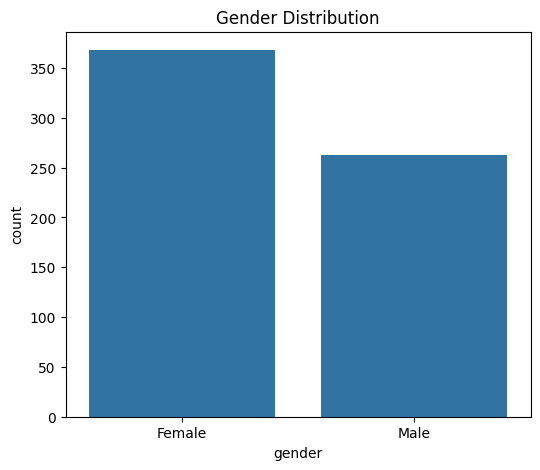

In [10]:
plt.figure(figsize=(6,5))

sns.countplot(
    data = sleep_gpa_df,
    x="gender"
)

plt.title("Gender Distribution")

plt.show()

**Observation:** Females are more represented than males in this dataset.

# 4. GPA by Gender

Question: Do male and female students perform differently?

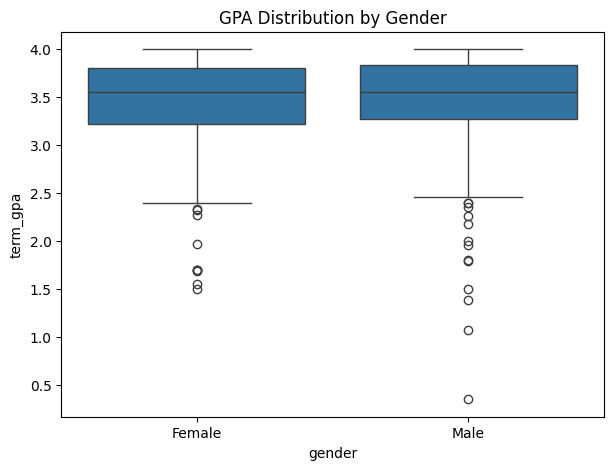

In [11]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=sleep_gpa_df,
    x= "gender",
    y= "term_gpa"
)

plt.title("GPA Distribution by Gender")

plt.show()

**Observation:** The boxplot indicates that the GPA distributions for male and female students are very similar. Both groups have nearly the same median GPA and comparable variability, suggesting that gender has little influence on GPA in this dataset. However, both groups contain several low-GPA outliers, with males exhibiting a few more extreme values.

# 5. GPA vs Sleep Hours

Question: Does Sleep have influence on GPA?

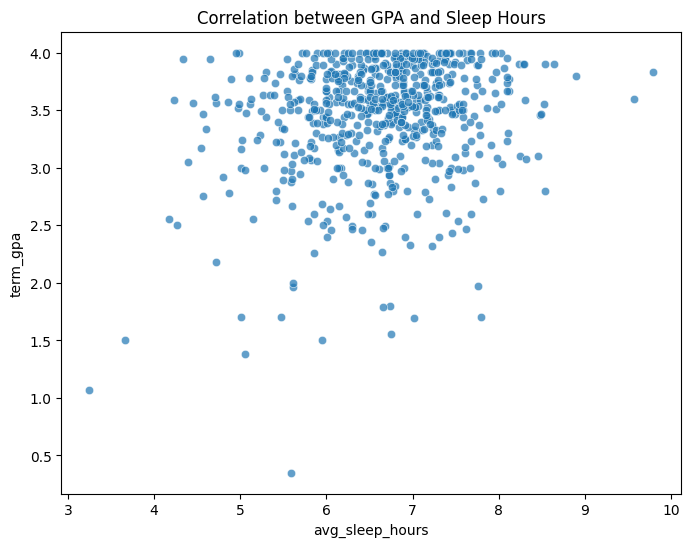

In [12]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=sleep_gpa_df,
    x="avg_sleep_hours",
    y="term_gpa",
    alpha= 0.7
)

plt.title("Correlation between GPA and Sleep Hours")

plt.show()

**Observation:** The scatter plot shows a weak positive relationship between average sleep hours and GPA. Most students who sleep 6–8 hours tend to have higher GPAs (around 3.4–4.0), although there is considerable variation. A few low-GPA outliers are present, indicating that sleep alone does not fully explain academic performance.

# 6. Correlation Heatmap

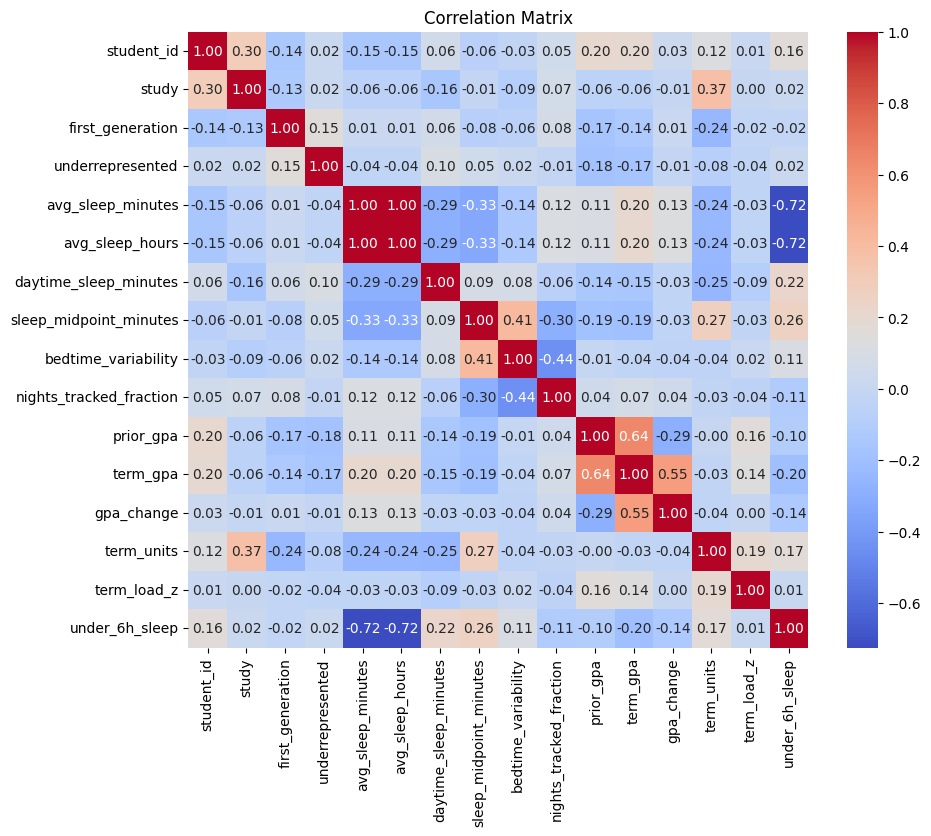

In [13]:
plt.figure(figsize=(10,8))

numeric = sleep_gpa_df.select_dtypes(include="number")

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

**Observation:**
* Prior GPA → Term GPA = 0.64
* This is a strong positive correlation.
* Students with higher previous GPA tend to have higher current GPA.
* GPA Change → Term GPA = 0.55
* Moderate to strong positive relationship.
* Average Sleep Hours → Term GPA = 0.20
* Weak positive relationship.
* Sleeping more is slightly associated with a higher GPA, but not strongly.
* Daytime Sleep → Term GPA = -0.15
* Weak negative relationship.
* More daytime sleep is slightly associated with a lower GPA.
* Under 6 Hours Sleep → Term GPA = -0.20
* Weak negative relationship.
* Students sleeping under 6 hours tend to have slightly lower GPAs.

The correlation matrix indicates that prior GPA (r = 0.64) has the strongest positive relationship with term GPA, suggesting previous academic performance is a good predictor of current performance. Sleep-related variables show only weak relationships with GPA. Average sleep hours have a weak positive correlation (r = 0.20), while sleeping less than six hours (r = -0.20) and daytime sleep (r = -0.15) have weak negative correlations with GPA.

# 7. Bedtime Variability vs GPA

Question: Does having a more irregular bedtime affect academic performance (term GPA)?

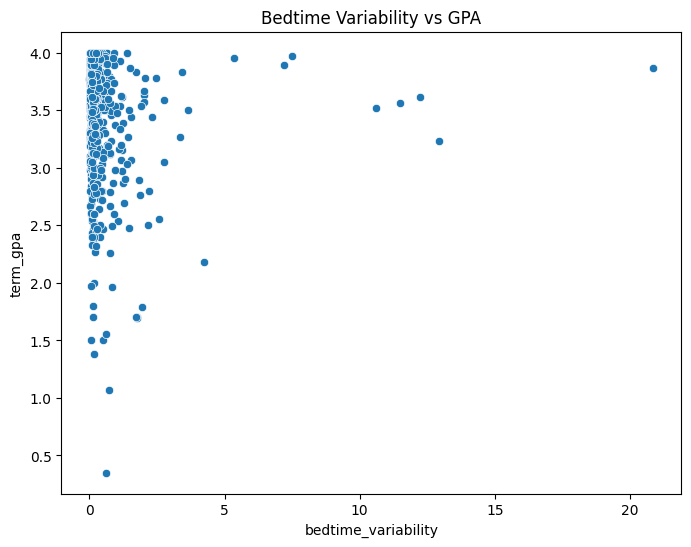

In [15]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=sleep_gpa_df,
    x="bedtime_variability",
    y="term_gpa"
)

plt.title("Bedtime Variability vs GPA")

plt.show()

**Observation:** The scatter plot shows no strong relationship between bedtime variability and term GPA. Most students have low bedtime variability (clustered near 0–2) with GPAs ranging from about 2.5 to 4.0. Although a few students have very high bedtime variability, they also tend to have relatively high GPAs. Overall, bedtime variability does not appear to be a strong predictor of academic performance in this dataset.

# Key Insights

1. **Most students achieved a high GPA.**
* The GPA distribution is concentrated between 3.2 and 4.0, indicating generally strong academic performance.

2. **Gender has little impact on GPA.**
* Male and female students have similar GPA distributions and median GPAs, suggesting no significant difference in academic performance by gender.

3. **Sleep duration has a weak positive relationship with GPA.**
* Students sleeping around 6–8 hours tend to have slightly higher GPAs, but the relationship is not strong.

4. **Prior academic performance is the strongest predictor of current GPA.**
* The correlation matrix shows that prior GPA (r = 0.64) has the highest positive correlation with term GPA.

5. **Irregular bedtime does not appear to significantly affect GPA.**
* The scatter plot and correlation analysis show almost no relationship between bedtime variability and academic performance.

6. **Sleeping less than six hours is slightly associated with lower GPA.**
* Students who frequently sleep fewer than six hours tend to have marginally lower GPAs.

# Conclusion

This analysis explored the relationship between sleep habits and academic performance among students. While sleep-related variables showed weak associations with GPA, prior academic performance was the strongest predictor of current GPA. Gender and bedtime variability had little influence on academic outcomes. Overall, maintaining healthy sleep habits may provide some academic benefits, but sleep alone does not fully explain differences in students' GPAs.